# DiSCo Python Test
Dieses Notebook testet die übersetzte Python-Version (`disco.py`) mit dem `dube` Datensatz, der auch in der R-Vignette (`Dube2019.Rmd`) verwendet wird.

In [18]:
import pandas as pd
import numpy as np
import pyreadr
import sys
from ipywidgets import interact, IntSlider
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Pfad hinzufügen, damit wir als Modul importieren können
sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo
from python.temp.data import get_continuous_data, generate_dynamic_panel_data, create_mdsc_panel_data, generate_multivariate_panel_dgp
from python.evaluation.visualization import (plot_fit_quantiles, plot_fit_cdf, plot_fit_copula, plot_fit_joint_contour,
plot_fit_scatter2d)

from python.tea import disco_tea

from python.evaluation.metrics import calculate_pretreatment_fit

In [28]:
import joblib

energy_results = joblib.load('disco_energy.pkl')
tangential_results = joblib.load('disco_mixture.pkl')
models = [energy_results, tangential_results]

In [29]:
#tea_ci = disco_tea(loaded_model, agg='transport_map', samples=[0.5])
for model in models:
    print(f'Min p-value: {1/model.perm.J_1:.4f}')
    print(f'Actual p-value: {model.perm.p_overall:.4f}')
    dist_mat = model.perm.distp.copy()

Min p-value: 0.0400
Actual p-value: 0.6154
Min p-value: 0.0400
Actual p-value: 0.3077


In [ ]:
model = swasserstein_results

dist_df = pd.DataFrame(dist_mat, columns=[f'Period {i+1}' for i in range(dist_mat.shape[1])], index=[f'Control {i+1}' for i in range(dist_mat.shape[0])])
dist_df.reset_index(inplace=True)
dist_df.rename(columns={'index': 'Unit'}, inplace=True)
dist_df = pd.concat([dist_df, pd.DataFrame({'Unit': ['Treated'], **{f'Period {i+1}': model.perm.distt[i] for i in range(model.perm.distt.shape[0])}})], ignore_index=True)

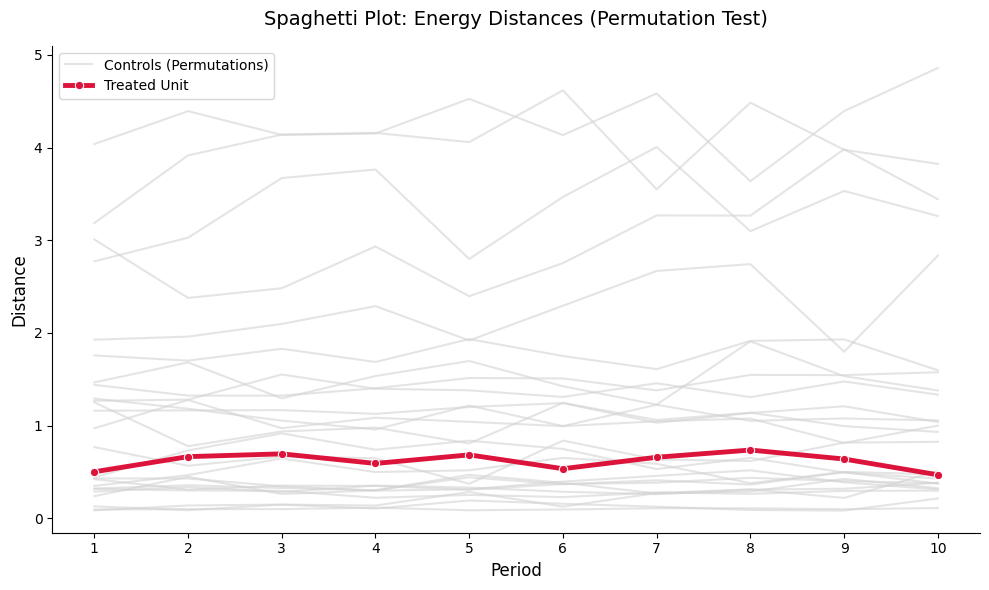

In [ ]:
df_long = pd.melt(
    dist_df, id_vars=["Unit"], var_name="Period", value_name="Distance"
)

# Optional: 'Period 1', 'Period 2' zu reinen Zahlen (1, 2) machen, damit die X-Achse sauber sortiert ist
df_long["Period_Num"] = (
    df_long["Period"].str.replace("Period ", "").astype(int)
)

# --- 2. Plot erstellen ---
plt.figure(figsize=(10, 6), dpi=100)

# Hintergrund: Alle Kontrollgruppen (Grau und dünn)
controls = df_long[df_long["Unit"] != "Treated"]
sns.lineplot(
    data=controls,
    x="Period_Num",
    y="Distance",
    units="Unit",  # Wichtig! Zeichnet für jede Unit eine eigene Linie
    estimator=None,  # Verhindert das Aggregieren/Mitteln der Daten
    color="lightgray",
    alpha=0.6,
    linewidth=1.5,
    label="Controls (Permutations)",
)

# Vordergrund: Die behandelte Einheit (Blau/Rot und dick)
treated = df_long[df_long["Unit"] == "Treated"]
sns.lineplot(
    data=treated,
    x="Period_Num",
    y="Distance",
    color="crimson",  # Schön sichtbares Rot für die Thesis
    linewidth=3.5,
    marker="o",  # Punkte auf den Perioden
    label="Treated Unit",
)

# --- 3. Styling & Beschriftung ---
plt.title(
    "Spaghetti Plot: Energy Distances (Permutation Test)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Period", fontsize=12)
plt.ylabel("Distance", fontsize=12)

# X-Achsen-Ticks sauber beschriften (jede Periode eine Zahl)
plt.xticks(np.arange(1, dist_mat.shape[1] + 1))

# Legende aufräumen (da 'controls' sonst für jede einzelne Unit ein Label erzeugen will)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    [by_label["Controls (Permutations)"], by_label["Treated Unit"]],
    ["Controls (Permutations)", "Treated Unit"],
    loc="upper left",
)

sns.despine()  # Entfernt den oberen und rechten Rahmen für einen cleanen Look
plt.tight_layout()
plt.show()

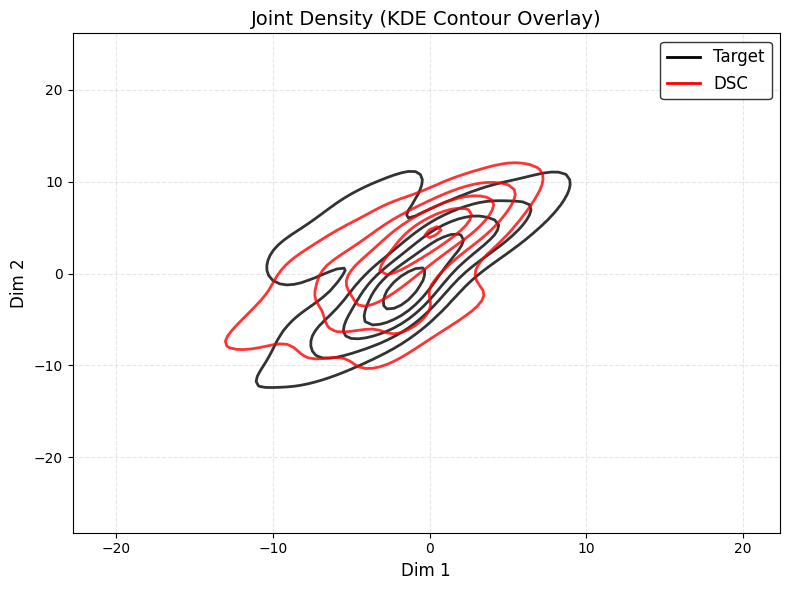

In [30]:
plot_fit_joint_contour(tangential_results, period=1)

In [ ]:
teat = disco_tea(loaded_model, agg='transport_map', samples=[0.1,0.9])

In [ ]:
teat.treats['Upper'][1]

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
Q1_Q1,0.1302,1.7549,0.0000,0.212,2.3360,0.0000,0.0,0.0000,0.0000
Q1_Q2,0.0000,2.3256,0.1891,0.000,3.0189,0.8457,0.0,0.0000,0.0000
Q1_Q3,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0,0.0000,0.0000
Q2_Q1,0.0259,0.0000,0.0000,0.316,5.9291,0.0000,0.0,0.0001,0.0000
Q2_Q2,0.0000,0.3854,0.0000,0.000,41.1629,31.3278,0.0,0.0000,0.0000
Q2_Q3,0.0000,0.0000,0.0000,0.000,0.0000,7.1608,0.0,0.0000,0.1917
Q3_Q1,0.0000,0.0000,0.0000,0.000,0.1080,0.0000,0.0,0.0001,0.0000
Q3_Q2,0.0000,0.0000,0.0000,0.000,1.9437,4.6224,0.0,0.2765,0.4018
Q3_Q3,0.0000,0.0000,0.0000,0.000,0.0000,2.8302,0.0,0.0000,0.6298


In [ ]:
joblib.dump(teat, 'tea/teat_result_no_treat_simple_dgp.pkl')

['tea/teat_result_no_treat_simple_dgp.pkl']

In [20]:
result_joint = joblib.load('disco_energy_joint.pkl')
result_separate = joblib.load('disco_energy_seperate.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'disco_energy_joint.pkl'

In [22]:
metrics_joint = calculate_pretreatment_fit(energy_results)

c:\Dokumente\Studium\1. Master Thesis\DiSCos\.venv\Lib\site-packages\ot\lp\_network_simplex.py:574: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)


In [31]:
metrics_separate = calculate_pretreatment_fit(tangential_results)

In [32]:
print(f'Wasserstein metrics (joint): {metrics_joint.w1}')
print(f'Wasserstein metrics (separate): {metrics_separate.w1}')
print(f'Energy metrics (joint): {metrics_joint.energy_divergence}')
print(f'Energy metrics (separate): {metrics_separate.energy_divergence}')

Wasserstein metrics (joint): 1.2379541965047625
Wasserstein metrics (separate): 1.3419186879764071
Energy metrics (joint): 0.6303827076957997
Energy metrics (separate): 1.0379931958869602


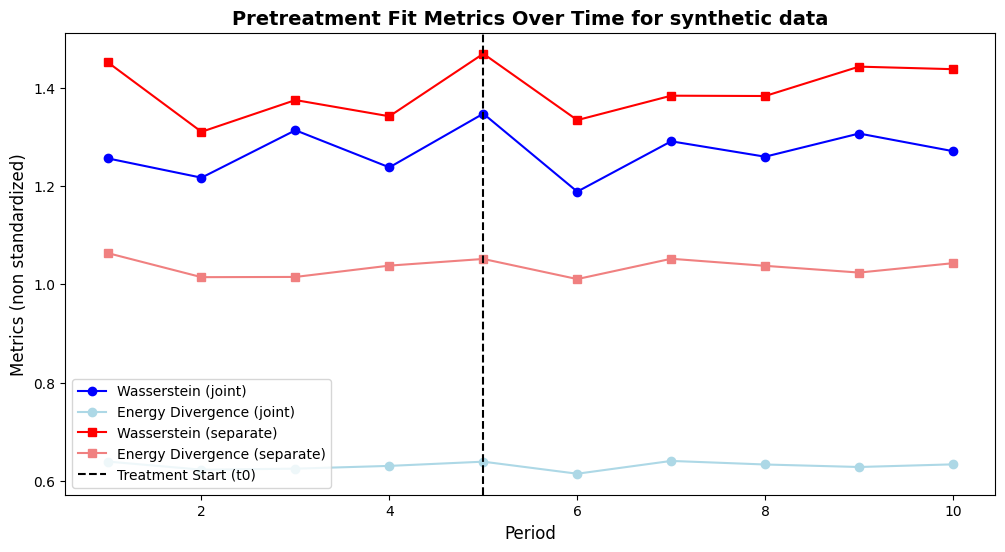

In [34]:
#create a line plot with the Wasserstein-1 distance over time for both joint and separate optimization, and add a vertical line at t0 to indicate the start of the treatment effect

# extract the Wasserstein-1 distance from metrics
periods = metrics_joint.metrics_per_period.keys()
w1_joint = [metrics_joint.metrics_per_period[t]['w1'] for t in periods]
energy_divergence_joint = [metrics_joint.metrics_per_period[t]['energy_divergence'] for t in periods]

w1_separate = [metrics_separate.metrics_per_period[t]['w1'] for t in periods]
energy_divergence_separate = [metrics_separate.metrics_per_period[t]['energy_divergence'] for t in periods]


df_joint = pd.DataFrame({
    'period': periods,
    'w1': w1_joint,
    'energy_divergence': energy_divergence_joint
})
df_separate = pd.DataFrame({
    'period': periods,
    'w1': w1_separate,
    'energy_divergence': energy_divergence_separate
})


# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df_joint['period'], df_joint['w1'], label='Wasserstein (joint)', color='blue', linestyle='-', marker='o')
plt.plot(df_joint['period'], df_joint['energy_divergence'], label='Energy Divergence (joint)', color='lightblue', linestyle='-', marker='o')
plt.plot(df_separate['period'], df_separate['w1'], label='Wasserstein (separate)', color='red', linestyle='-', marker='s')
plt.plot(df_separate['period'], df_separate['energy_divergence'], label='Energy Divergence (separate)', color='lightcoral', linestyle='-', marker='s')
plt.axvline(x=5, color='black', linestyle='--', label='Treatment Start (t0)')
plt.title('Pretreatment Fit Metrics Over Time for synthetic data', fontsize=14, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('Metrics (non standardized)', fontsize=12)
plt.legend(loc='best')
plt.show()

In [ ]:
# wide comparison:
results_swasserstein = DiSCo(
    method='wasserstein',
    joint_opt=False,
    **arguments).fit()

results_mixture = DiSCo(
    method='mixture',
    joint_opt=False,
    **arguments).fit()

results_tangential = DiSCo(
    method='tangential',
    joint_opt=False,
    **arguments).fit()

metrics_swasserstein = calculate_pretreatment_fit(results_swasserstein)
metrics_mixture = calculate_pretreatment_fit(results_mixture)
metrics_tangential = calculate_pretreatment_fit(results_tangential)

sparsity_swasserstein = np.sum(results_swasserstein.results_periods[1.0].DiSCo.weights > 1e-6)
sparsity_mixture = np.sum(results_mixture.results_periods[1.0].DiSCo.weights > 1e-6)
sparsity_tangential = np.sum(results_tangential.results_periods[1.0].DiSCo.weights > 1e-6)
sparsity_energy_seperate = np.sum(result_separate.results_periods[1.0].DiSCo.weights > 1e-6)
sparsity_energy_joint = np.sum(result_joint.results_periods[1.0].DiSCo.weights > 1e-6)

comp_df = pd.DataFrame({
    'Method': ['Energy_Joint','Energy_Seperate','S-Wasserstein','Tangential','Mixture'],
    'Wasserstein.1': [metrics_joint.w1, metrics_separate.w1, metrics_swasserstein.w1, metrics_tangential.w1, metrics_mixture.w1],
    'Energy Divergence': [metrics_joint.energy_divergence, metrics_separate.energy_divergence, metrics_swasserstein.energy_divergence, metrics_tangential.energy_divergence, metrics_mixture.energy_divergence],
    'Sparsity': [sparsity_energy_joint, sparsity_energy_seperate, sparsity_swasserstein, sparsity_tangential, sparsity_mixture]
})

comp_df_melted = comp_df.melt(id_vars='Method', var_name='Metric', value_name='Value')
comp_df_melted


,Method,Metric,Value
0,Energy_Joint,Wasserstein.1,0.569911
1,Energy_Seperate,Wasserstein.1,0.499015
2,S-Wasserstein,Wasserstein.1,0.609246
3,Tangential,Wasserstein.1,0.601363
4,Mixture,Wasserstein.1,0.516454
5,Energy_Joint,Energy Divergence,0.260515
6,Energy_Seperate,Energy Divergence,0.111355
7,S-Wasserstein,Energy Divergence,0.123198
8,Tangential,Energy Divergence,0.104300
9,Mixture,Energy Divergence,0.122192


# REAL DATASETS

In [ ]:
dube_large = pd.read_csv('../datasets/dube_combined.csv')

In [ ]:
dube_small = pd.read_csv('../datasets/dube_small.csv')

In [ ]:
matched = pd.read_stata('../datasets/data3/data/matchedCPS_1979_2016.dta')

In [ ]:
reader = pd.io.stata.StataReader('../datasets/data3/data/matchedCPS_1979_2016.dta')
labels = reader.variable_labels()

# In ein DataFrame umwandeln für die Suche
df_meta = pd.DataFrame(list(labels.items()), columns=['Variable', 'Beschreibung'])

# Suche nach Lohn- und Stundenvariablen
search = df_meta[df_meta['Variable'].str.contains('wage|hour|earn', case=False)]
print(search)

              Variable                             Beschreibung
17            uhours_1                         (dp) Usual hours
18            earnhr_1                   (dp) Earnings per hour
19           uearnwk_1             (dp) Usual earnings per week
20            earnwt_1  (dp) Earnings weight for all races x100
21           uhourse_1                       (e&dp) Usual hours
23           earnhre_1                 (e&dp) Earnings per hour
24           earnwke_1                 (e&dp) Earnings per week
53              wage_1                                         
54      hoursimputed_1                                         
55   earningsimputed_1                                         
56       wageimputed_1                                         
58         orig_wage_1                                         
85              uhours                         (dp) Usual hours
86              earnhr                   (dp) Earnings per hour
87             uearnwk             (dp) 

In [ ]:
matched.groupby(['year', 'statenum'])['earnwke'].count().sort_values() 

year  statenum
1986  35.0         121
      8.0          127
      5.0          139
      41.0         140
      56.0         144
                  ... 
1980  6.0         5085
1984  6.0         5191
1981  6.0         5195
1983  6.0         5208
1982  6.0         5210
Name: earnwke, Length: 1887, dtype: int64

In [ ]:
matched.shape

(3642039, 136)